<h1> Imports & Installs </h1>

In [1]:
!pip install scikit-image


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from scipy import ndimage
from skimage.feature import blob_log
from skimage.color import rgb2gray

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)

<h1> Loading Image </h1>

In [3]:
# For now, the Image Path must be set.
IMAGE_PATH = "images/edited image.jpg"  

try:
    image = np.array(Image.open(IMAGE_PATH).convert("RGB"))
    print(f"Loaded image: {IMAGE_PATH}, shape={image.shape}")
except FileNotFoundError:
    image = None
    print("No file found at IMAGE_PATH. Run the next cell to generate a synthetic starfield instead.")

Loaded image: images/edited image.jpg, shape=(2268, 4032, 3)


# Normalizing / Greyscale the Image
<li> Note: Most of these steps can be substitute via Joey's Algorithm handling the Filtering / Pre-Processing Section</li>

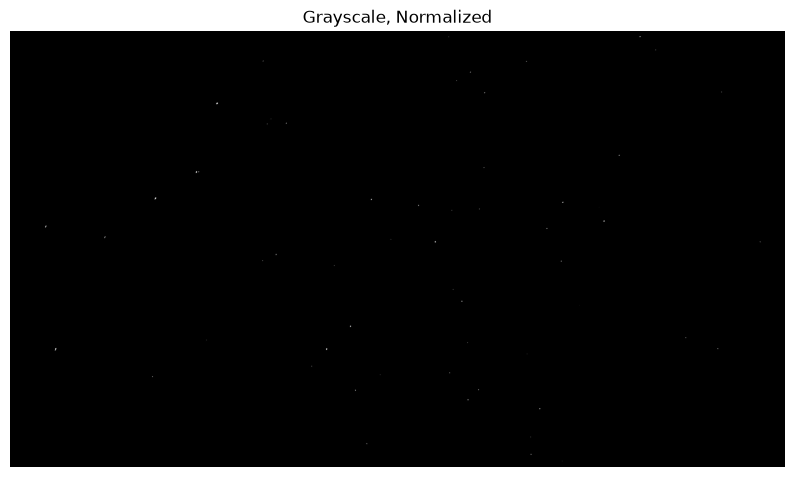

In [4]:
gray = rgb2gray(image)  # values now in range [0, 1]

# Normalize to use the full 0-1 range, in case the image doesn't already
gray_norm = (gray - gray.min()) / (gray.max() - gray.min())

plt.imshow(gray_norm, cmap='gray')
plt.title("Grayscale, Normalized")
plt.axis('off')
plt.show()

<h1> Filtering Phase </h1>

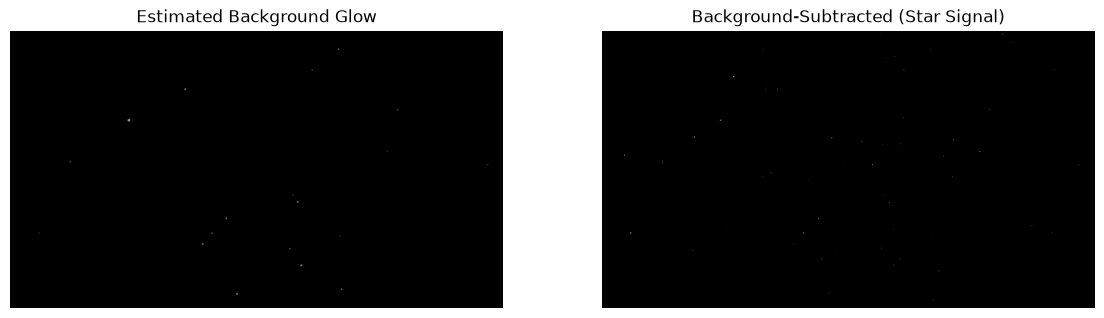

In [5]:
# A large median filter smooths out small bright dots (stars) but keeps
# the slow-varying background glow intact.
background_estimate = ndimage.median_filter(gray_norm, size=25)

# Subtracting it leaves mostly just the sharp, star-like features
star_signal = gray_norm - background_estimate
star_signal = np.clip(star_signal, 0, None)  # discard negative dips

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(background_estimate, cmap='gray')
axes[0].set_title("Estimated Background Glow")
axes[0].axis('off')
axes[1].imshow(star_signal, cmap='gray')
axes[1].set_title("Background-Subtracted (Star Signal)")
axes[1].axis('off')
plt.show()

<h1> Candidate Star Detection via Blobs</h1>

In [6]:
blobs = blob_log(
    star_signal,
    min_sigma=1,
    max_sigma=4,
    num_sigma=8,
    threshold=0.05
)

# blob_log returns (y, x, sigma) for each detection.
# Convert sigma to an approximate display radius.
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

print(f"Detected {len(blobs)} candidate stars before filtering.")

Detected 62 candidate stars before filtering.


In [7]:
MIN_BRIGHTNESS = 0.15   # minimum normalized pixel value to count as a real star
EDGE_MARGIN = 5         # pixels away from the border required

filtered_blobs = []
for (y, x, r) in blobs:
    y, x = int(round(y)), int(round(x))
    if not (EDGE_MARGIN <= y < gray_norm.shape[0] - EDGE_MARGIN):
        continue
    if not (EDGE_MARGIN <= x < gray_norm.shape[1] - EDGE_MARGIN):
        continue
    brightness = gray_norm[y, x]
    if brightness < MIN_BRIGHTNESS:
        continue
    filtered_blobs.append((y, x, r, brightness))

print(f"{len(filtered_blobs)} stars remain after filtering (from {len(blobs)} candidates).")

62 stars remain after filtering (from 62 candidates).


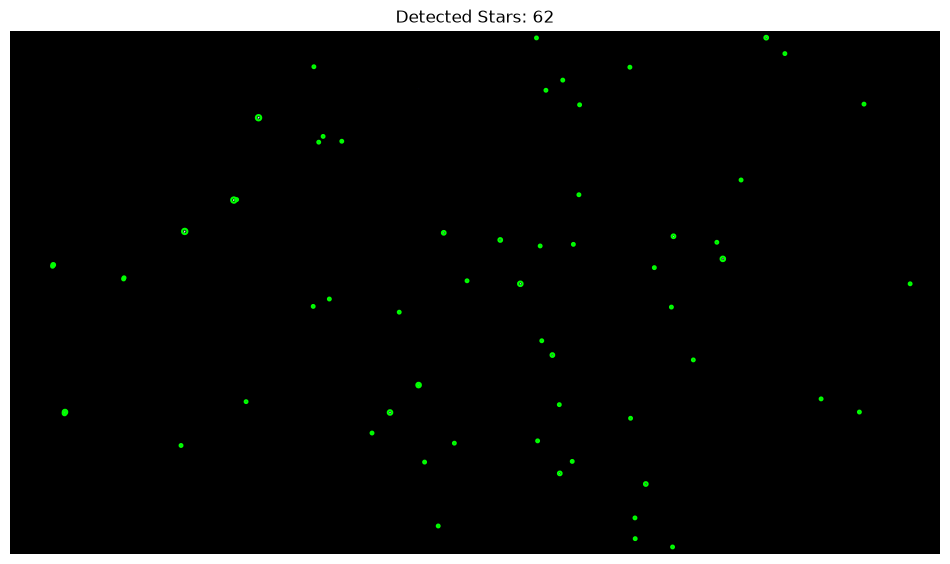

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Detected Stars: {len(filtered_blobs)}")
ax.axis('off')

for (y, x, r, brightness) in filtered_blobs:
    circle = patches.Circle((x, y), radius=max(r * 3, 6), fill=False,
                             edgecolor='lime', linewidth=1.5)
    ax.add_patch(circle)

plt.show()

In [9]:
# Displaying the Star Candidates in a dataframe
import pandas as pd

results_df = pd.DataFrame(
    filtered_blobs, columns=["y (row)", "x (col)", "size (sigma)", "brightness (0-1)"]
).sort_values("y (row)", ascending=True).reset_index(drop=True)

results_df

,y (row),x (col),size (sigma),brightness (0-1)
0,29,3278,2.626397,0.977907
1,30,2282,1.414214,0.969167
2,98,3359,1.414214,0.988333
3,155,1317,1.414214,0.974167
4,157,2687,2.020305,0.976667
...,...,...,...,...
57,1964,2756,2.626397,0.995000
58,2111,2709,1.414214,0.977500
59,2146,1856,2.020305,0.964167
60,2201,2710,2.020305,0.965833


# KNN Section 
<p> Pathways (For Latitide)</p>
<li> Identification through North Star (Exclusive to North Hemisphere)
    <li>
        asd
    </li>
<li> Identification Using Southern Cross (Exclusive to South Hemisphere)
<li> Identification Using Rising and Setting Positions of Constellations
</li>


In [10]:
class Star_KNN:
  def __init__(self, k):
    self.k = k

  #Train Model on Images
  def fit(self, X_train, y_train):
    return

  #Euclidean Distance Function
  def Euclidean_distance(self, x1, x2):
    return np.sqrt(np.sum((x1-x2)**2))

  #Manhattan Distance Function
  def Manhattan_distance(self, x1, x2):
    return np.sum(np.abs(x1 - x2))

  #Minkowski Distance Function
  def Minkowski_distance(self, x1, x2, p):
    return (np.sum(np.abs(x1- x2)**p))**(1/p)


## DBSCAN
</h1>
<p >
    This section was created as a proof of concept to visually see WHat identified grouping of stars could give us in terms of information. This looked like it accomplishing something rather than actually having anything of value. The best information I was able to derive from ths section is that the angular differential distance between pair of stars are stronger ways to identify these star patterns rather than using brightness value of these stars.
<li>
    Not relying on the Brightness & "Blob Size" of the star would be ideal considering that these factors are inherently limited by the Focal Lens taken and the Pre-Processing Section being sufficient.
<li> It should be considered when validity of consellations however.
</li>
</p>

In [11]:
#Clustering the Points
#MetaData we will be using
    #Location / Descenesion
    # X / y Coordinates
import pandas as pd
from sklearn.cluster import DBSCAN
data = results_df
location_x, location_y = data['x (col)'], data['y (row)']
test_df = pd.DataFrame({ data.columns[0] : location_x,
                    data.columns[1] : location_y})
dfe = results_df[[data.columns[1], data.columns[0]]].values
db = DBSCAN(eps = 400.0, min_samples=2) #utilizing DBSCAN from scikit-learn for use of proof of concept
                                        #Ideally, we replace this later with a more appropiate model
test_df['cluster'] = db.fit_predict(dfe)
test_df


,y (row),x (col),cluster
0,3278,29,0
1,2282,30,1
2,3359,98,0
3,1317,155,2
4,2687,157,1
...,...,...,...
57,2756,1964,1
58,2709,2111,1
59,1856,2146,1
60,2710,2201,1


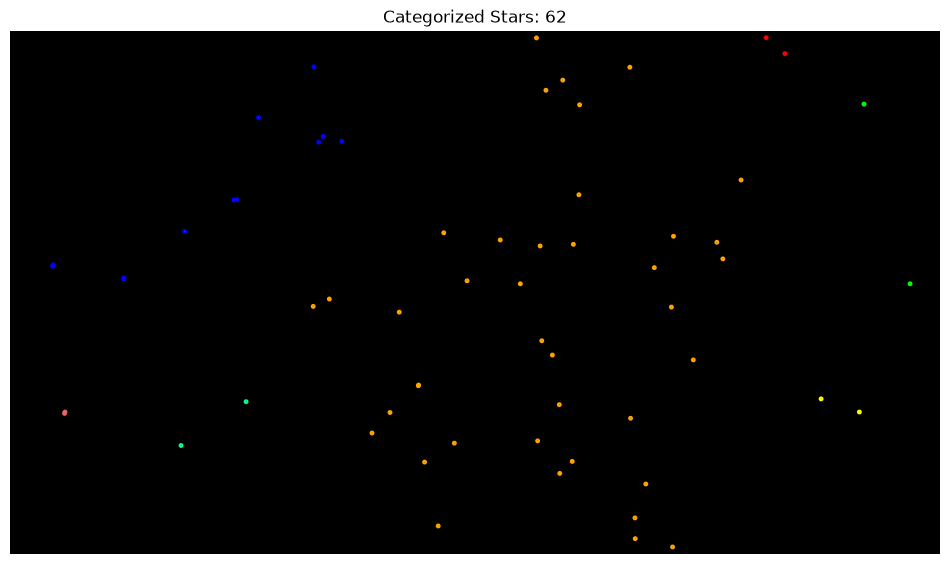

In [12]:
#SHowcasing the Clustered Points
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Categorized Stars: {len(test_df)}")
ax.axis('off')
colorcode = {
    -1 : 'lime',
    0 : 'red',
    1 : 'orange',
    2 : 'blue',
    3 : 'yellow',
    4 : '#00ff8f',
    5 : '#e36868'
}
for row in test_df.itertuples():
    circle = patches.Circle((row[1], row[2]), radius = max(r*3, 6), 
    fill = False, edgecolor = colorcode.get(row.cluster), linewidth = 1.5)
    ax.add_patch(circle)
plt.show()


## Root A (TKGRE)
<body>
Each Star, from a Image Processing Lens, gather 4 features:
    <li>Coordinates (X,Y)
    <li>Brightness Value
    <li>Blob Size
</li>
Due to this, in order to start identifying Star Patterns, we'd be utilizing the Distance between star constellations being constant to identify the Latitude.
The Latitude is dependent not on the distance between constellations, but what stars were visible.
</body>

### Star Class

In [20]:
class Star:
    def __init__(self, detail : list):
        self.x_Value = detail[0]
        self.y_Value = detail[1]
        self.blob_size = detail[2]
        self.brightness = detail[3]
        self.left = None
        self.right = None
        
    def attach_right(self, st_1):
        self.right = st_1
        st_1.left = self
        
    def attach_left(self, st_2):
        self.left = st_2
        st_2.right = self

    def get_x_Value(self):
        return float(self.x_Value)

    def get_y_Value(self):
        return float(self.y_Value)

    #Returns the Coordinates Set
    def get_Coordinates(self):
        return [self.x_Value, self.y_Value]
        
    #Gets Length of Star Connections
    def get_length(self, depth = 0, prev_star = None):
        depth += 1
        if self.left != None and self.left != prev_star:
            depth = self.left.get_length(depth, self)
        if self.right != None and self.right != prev_star:
            depth = self.right.get_length(depth, self)
        return depth
        
    #Prints Off Summary of Star Values
    def __str__(self):
        return f" Coordinates:{self.x_Value}, {self.y_Value}\n Blob Size:{self.blob_size}\n Brightness: {self.brightness}"
        
    def print_rigid(self):
        star_graph = list()
        star_graph.append(self)
        if self.left != None:
            star_graph = self.left.print_rigid()
        if self.right != None:
            star_graph = self.right.print_rigid()
        return star_graph

    
    #Prints Star's Connections (Should they exist)
    def print_structure(self):
        star_graph = ""
        star_graph += f"{self}"
        
        if self.left != None:
            star_graph += f"\n\t LEFT -> {self.left}"
        else:
            star_graph += f"\n\t LEFT -> None"
        if self.right != None:
            star_graph += f"\n\t RIGHT -> {self.right}"
        else:
            star_graph += f"\n\t RIGHT -> None"
        return star_graph

### Helpers

In [21]:
def Starter_kit(stars_scanned) -> list:
    Star_list = list()
    for index,row in stars_scanned.iterrows():
        detail = list([row['x (col)'], row['y (row)'], row['size (sigma)'],row['brightness (0-1)']])
        Star_list.append(Star(detail))
    return Star_list

In [22]:
def star_topcandidates(Star_List : list, distance_matrix) -> list:
    testing = Star_List.pop(0)
    candidates_list = list()
    for row in Star_list:
        value = distance_matrix(testing, row)
        candidates_list.append([row, float(value)])
    candidates_list.sort(key = lambda x : x[1])
    top_candidates = candidates_list[0:9]
    return testing, top_candidates

In [23]:
def form_stars(mid_star : Star, st_1 : Star, st_2 : Star = None) -> None:
    if st_2 is not None:
        
        if min([st_1, st_2], key = lambda x: x.get_x_Value()).get_x_Value() > mid_star.get_x_Value():
            form_stars(st_1, mid_star, st_2)
            return
        if st_2.x_Value > mid_star.x_Value:
            mid_star.attach_left(st_1)
            mid_star.attach_right(st_2)
            
        else:
            mid_star.attach_left(st_2)
            mid_star.attach_right(st_1)
    else:
        if st_1.x_Value > mid_star.x_Value:
            mid_star.right = st_1
        

In [ ]:
def form_stars_two(mid_star : Star, st_1 : Star,

In [24]:
def find_mid_star(star : Star) -> Star:
    if star.left != None and star.right != None:
        return star
    else:
        mid_star = None
        if star.left != None and mid_star == None:
            mid_star = find_mid_star(star.left)
        if star.right != None and mid_star == None:
            mid_star = find_mid_star(star.right)
    return mid_star

In [25]:
def connect_all_stars(star : Star, prev_star : Star = None, star_list : list = list()) -> list:
    if star.left != None and star.left != prev_star:
        star_list = connect_all_stars(star, prev_star)
    star_list.append(star)
    if star.right != None and star.right != prev_star:
        star_list = connect_all_stars(star.right, star, star_list)
    return star_list

### Distance Matrixes

In [27]:
def Manhattan_distmtx(st_1 : Star, st_2 : Star):
    return np.abs(st_2.x_Value - st_1.x_Value) + np.abs(st_2.y_Value - st_1.y_Value)

In [26]:
def Euclidean_distmtx(st_1 : Star, st_2 : Star):
    return np.sqrt((st_2.x_Value - st_1.x_Value)**2 + (st_2.y_Value - st_1.y_Value)**2)

### Testing & Execution

In [28]:
##Grabs The StarMap Dataframe and turns it into a usable List
Star_list = Starter_kit(results_df)
candidate, star_candidates_list = star_topcandidates(Star_list, Euclidean_distmtx)

In [29]:
form_stars(candidate, star_candidates_list[0][0], star_candidates_list[1][0])

In [30]:
loopingthru = connect_all_stars(candidate)

In [31]:
print(len(loopingthru))

3


In [32]:
for star in loopingthru:
    print(star)

 Coordinates:3278.0, 29.0
 Blob Size:2.6263966158357483
 Brightness: 0.9779070588235295
 Coordinates:3359.0, 98.0
 Blob Size:1.4142135623730951
 Brightness: 0.9883333333333333
 Coordinates:3702.0, 317.0
 Blob Size:1.4142135623730951
 Brightness: 0.9883333333333333


In [33]:
print(candidate.get_length())

3


In [ ]:
def star_group_identification()

In [65]:
def form_stars_two(st_1 : Star, st_2 : Star, prev_star : Star = None):
    if st_1.x_Value < st_2.x_Value:
        if st_1.right is None:
            st_1.right = st_2
            st_2.left = st_1
        else:
            if prev_star != None:
                prev_star.left = st_2
                st_2.right = prev_star
                st_1.right = st_2
                st_2.left = st_1
                return
            form_stars_two(st_1.right, st_2, st_1)
    else:
        if st_1.left is None:
            st_2.right = st_1
            st_1.left = st_2
        else:
            if prev_star != None:
                prev_star.right = st_2
                st_2.left = prev_star
                st_2.right = st_1
                st_1.left = st_2
                return
            form_stars_two(st_1.left, st_2, st_1)
    

In [ ]:
def star_glaze_group(Star_list : list, max_size : int):
    while len(Star_list) != 0:
        candidate, star_candidates_list = star_topcandidates(Star_list, Manhattan_distmtx)
        for x in len(max_size):
            form_stars_two(candidate, star_candidates_list[x][0])
            
            
                       
            


In [70]:
Star_list = Starter_kit(results_df)
new_map = list()
candidate, star_candidates_list = star_topcandidates(Star_list, Manhattan_distmtx)
print(star_candidates_list)
while len(Star_list) != 0:
        candidate, star_candidates_list = star_topcandidates(Star_list, Manhattan_distmtx)
        for x in range(2):
            print(x)
            form_stars_two(candidate, star_candidates_list[x][0])

[[<__main__.Star object at 0x73860e328250>, 150.0], [<__main__.Star object at 0x73860e3286d0>, 712.0], [<__main__.Star object at 0x73860e3282d0>, 719.0], [<__main__.Star object at 0x73860e328a50>, 726.0], [<__main__.Star object at 0x73860e3280d0>, 997.0], [<__main__.Star object at 0x73860e328550>, 1066.0], [<__main__.Star object at 0x73860e328450>, 1100.0], [<__main__.Star object at 0x73860e328dd0>, 1101.0], [<__main__.Star object at 0x73860e328bd0>, 1147.0]]
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1
0
1


IndexError: list index out of range

In [38]:
Star_list = Starter_kit(results_df)
new_map = list()
while len(Star_list) != 0:
    candidate, star_candidates_list = star_topcandidates(Star_list, Manhattan_distmtx)
    print(len(star_candidates_list))
    if len(star_candidates_list) > 1:
        form_stars(candidate, star_candidates_list[0][0], star_candidates_list[1][0])
        Star_list.remove(star_candidates_list[0][0])
        Star_list.remove(star_candidates_list[1][0])
    else:
        form_stars(candidate, star_candidates_list[0][0], None)
        Star_list.remove(star_candidates_list[0][0])
    print(candidate.get_length())
    new_map.append(candidate)


9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
9
3
7
3
4
3
1
2


In [35]:
for star_group in new_map:
    print(find_mid_star(star_group).print_structure())

 Coordinates:3359.0, 98.0
 Blob Size:1.4142135623730951
 Brightness: 0.9883333333333333
	 LEFT ->  Coordinates:3278.0, 29.0
 Blob Size:2.6263966158357483
 Brightness: 0.9779070588235295
	 RIGHT ->  Coordinates:3702.0, 317.0
 Blob Size:1.4142135623730951
 Brightness: 0.9883333333333333
 Coordinates:2323.0, 257.0
 Blob Size:1.4142135623730951
 Brightness: 0.9566666666666668
	 LEFT ->  Coordinates:2282.0, 30.0
 Blob Size:1.4142135623730951
 Brightness: 0.9691666666666667
	 RIGHT ->  Coordinates:2396.0, 213.0
 Blob Size:2.0203050891044216
 Brightness: 0.9875
 Coordinates:1357.0, 457.0
 Blob Size:1.4142135623730951
 Brightness: 0.9666666666666668
	 LEFT ->  Coordinates:1338.0, 482.0
 Blob Size:1.4142135623730951
 Brightness: 0.9616666666666667
	 RIGHT ->  Coordinates:1317.0, 155.0
 Blob Size:1.4142135623730951
 Brightness: 0.9741666666666666
 Coordinates:2687.0, 157.0
 Blob Size:2.0203050891044216
 Brightness: 0.9766666666666668
	 LEFT ->  Coordinates:2466.0, 710.0
 Blob Size:2.020305089104

AttributeError: 'NoneType' object has no attribute 'print_structure'

AttributeError: 'NoneType' object has no attribute 'left'

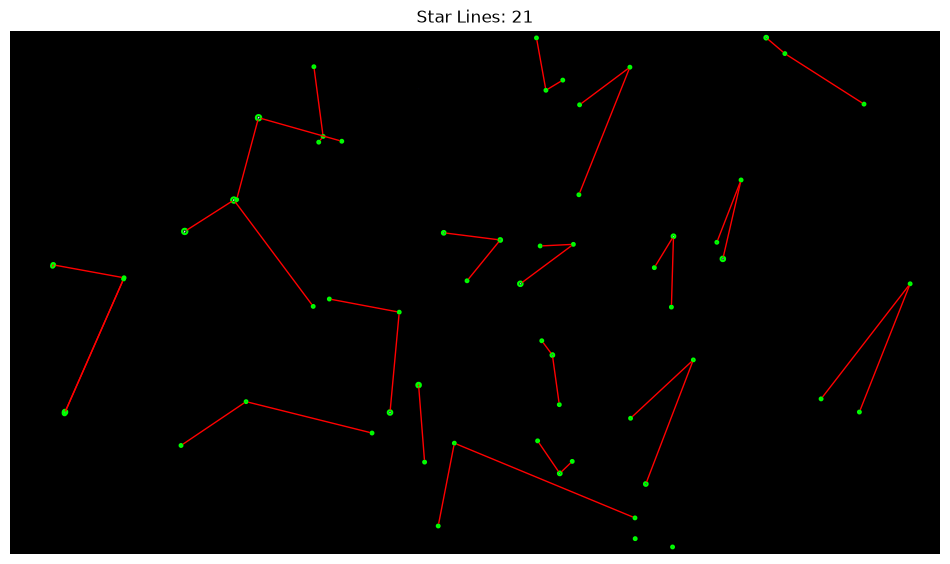

In [36]:
#import matplotlib.patches.FancyArrowPatch as arrpath
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)
ax.set_title(f"Star Lines: {len(new_map)}")
ax.axis('off')

for (y, x, r, brightness) in filtered_blobs:
    circle = patches.Circle((x, y), radius=max(r * 3, 6), fill=False,
                             edgecolor='lime', linewidth=1.5)
    ax.add_patch(circle)

#Prototype - Interconnect seperate lines between points
    # Fix Bug with Lower Than average Star Count
'''
test_1 =  new_map[0]
test_2 =  test_1.right
x = [float(test_1.x_Value), float( test_1.y_Value)]
y = [ float(test_2.x_Value), float(test_2.y_Value)]
'''

for star_group in new_map:
    mid_star = find_mid_star(star_group)
    x = mid_star.left.get_Coordinates()
    y = mid_star.get_Coordinates()
    z = mid_star.right.get_Coordinates()
    line_patch = patches.FancyArrowPatch(
        posA = x, 
        posB = y, 
        arrowstyle = "-",     
        color = "red", 
        linewidth = 1
    )
    ax.add_patch(line_patch)
    line_patch = patches.FancyArrowPatch(
        posA = y,
        posB = z,
        arrowstyle = "-",
        color = "red",
        linewidth = 1
    )
    ax.add_patch(line_patch)
    
plt.show()